# Bending Spoons Technical Task - Presentation View
**Ad Performance Dataset: analysis by Yung-Hsuan Wu**

This notebook contains the data analysis and visualization code I wrote for Bending Spoons technical task, based on Bending Spoons' provided Ad Performance Dataset.

It accompanies the Google Slide deck shared together with the submission form, and it only includes code for generating analysis used in the final presentation.

For the full notebook including more details and explanations, please see ```yhw-task-submission-full.ipynb```.

This notebook is meant for a technical analyst to read, and the Google Slide deck is written with a general non-technical audience in mind.

# Introduction

# Technical setup
In this section, I prepared commands that would help set up the technical environment for running this notebook. 

In [1]:
# Before running the notebook, please uncomment the following to install all dependencies:
# !pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Data preparation and structure
In this section, I demonstrate how I loaded, inspected, and cleaned the data before the analysis. Run it all at once to get the finalized data for analysis. 

1. Inspect data (read, shape, and types)
2. Beautify column names for better indexing
3. Check for NaN/null/duplicate values: **no missing values nor duplicates found!**
4. Segment data by relevant dates
5. Join relevant parts of ad and download data
6. Verify metrics to ensure data consistency
7. Expand dataset with missing yet potentially informative metrics (e.g., absolutes)

In [3]:
# 1. Inspect data and check for data types and shape

xlsx = pd.ExcelFile("ad_performance/Ad Performance Dataset.xlsx")
ad_df = pd.read_excel(xlsx, "Ad Data")
download_df = pd.read_excel(xlsx, "Downloads timeseries")

print(f"Ad data has shape {ad_df.shape}")
print(f"First five rows of Ad data:\n{ad_df.head()}")
print(f"Data types of each column in Ad data:\n{ad_df.dtypes}")

print(f"Download data has shape: {download_df.shape}")
print(f"First five rows of Downloads data:\n{download_df.head()}")
print(f"Data types of each column in Download data:\n{download_df.dtypes}")

Ad data has shape (86, 8)
First five rows of Ad data:
        Date  Ad spend   CPM     CTR  Paid downloads    CPI  \
0 2025-10-07        36  0.91  0.0480            1363  0.026   
1 2025-10-08        90  0.90  0.0449            3123  0.029   
2 2025-10-09        90  1.04  0.0460            2787  0.032   
3 2025-10-10        87  1.01  0.0433            2500  0.035   
4 2025-10-11        90  0.92  0.0401            2583  0.035   

   ARPD (on paid downloads)  APPD (on paid downloads)  
0                     0.084                     0.058  
1                     0.083                     0.054  
2                     0.063                     0.031  
3                     0.067                     0.032  
4                     0.081                     0.046  
Data types of each column in Ad data:
Date                        datetime64[us]
Ad spend                             int64
CPM                                float64
CTR                                float64
Paid downloads       

In [4]:
# 2. Beautify column names for exploration
ad_columns_rename = {
  "Date": "date",
  "Ad spend": "ad_spend",
  "CPM": "cpm",
  "CTR": "ctr",
  "Paid downloads": "paid_downloads",
  "CPI": "cpi",
  "ARPD (on paid downloads)": "arpd",
  "APPD (on paid downloads)": "appd"
}

download_df_rename = {
  "Date": "date",
  "Total downloads": "total_downloads"
}

ad_df = ad_df.rename(columns=ad_columns_rename).copy()
download_df = download_df.rename(columns=download_df_rename).copy()

print(f"ad_df column names now:\n{ad_df.columns}")
print(f"download_df column names now:\n{download_df.columns}")

ad_df column names now:
Index(['date', 'ad_spend', 'cpm', 'ctr', 'paid_downloads', 'cpi', 'arpd',
       'appd'],
      dtype='str')
download_df column names now:
Index(['date', 'total_downloads'], dtype='str')


In [5]:
# 3. Check for NaN values and duplicates
print(f"Missing values per column in ad_df:\n{ad_df.isna().sum()}")
print(f"Missing values per column in download_df:\n{download_df.isna().sum()}")
print(f"Duplicate dates in ad_df: {ad_df.date.duplicated().sum()}")
print(f"Duplicate dates in download_df: {download_df.date.duplicated().sum()}")

Missing values per column in ad_df:
date              0
ad_spend          0
cpm               0
ctr               0
paid_downloads    0
cpi               0
arpd              0
appd              0
dtype: int64
Missing values per column in download_df:
date               0
total_downloads    0
dtype: int64
Duplicate dates in ad_df: 0
Duplicate dates in download_df: 0


In [6]:
# 4. Segment data for usage
# Verify date ranges of the data
ad_date_range = [ad_df.date.dt.date.min(), ad_df.date.dt.date.max()]
print(f"ad_df ranges from {str(ad_date_range[0])} to {str(ad_date_range[1])}")

download_date_range = [download_df.date.dt.date.min(), download_df.date.dt.date.max()]
print(f"download_df ranges from {str(download_date_range[0])} to {str(download_date_range[1])}")

ad_df ranges from 2025-10-07 to 2025-12-31
download_df ranges from 2025-08-01 to 2025-12-31


In [7]:
# Since the app-install campaign only ran from October 7, 2025 to December 31, 2025, I sliced the download df into pre- and post-promotion campaign
promo_st = pd.to_datetime(ad_date_range[0])

prepromo_download_df = download_df[download_df.date < promo_st]
postpromo_download_df = download_df[download_df.date >= promo_st]

print(f"prepromo_download_df ranges from {str(prepromo_download_df.date.dt.date.min())} to {str(prepromo_download_df.date.dt.date.max())}")
print(f"prepromo_download_df has {prepromo_download_df.shape[0]} rows")
print(f"postpromo_download_df ranges from {str(postpromo_download_df.date.dt.date.min())} to {str(postpromo_download_df.date.dt.date.max())}")
print(f"postpromo_download_df has {postpromo_download_df.shape[0]} rows")

# I also set date to be index as all dfs are timeseries data
ad_df = ad_df.set_index("date").copy()
download_df = download_df.set_index("date").copy()
prepromo_download_df = prepromo_download_df.set_index("date").copy()
postpromo_download_df = postpromo_download_df.set_index("date").copy()

prepromo_download_df ranges from 2025-08-01 to 2025-10-06
prepromo_download_df has 67 rows
postpromo_download_df ranges from 2025-10-07 to 2025-12-31
postpromo_download_df has 86 rows


In [8]:
# 5. Join relevant parts of ad and download data
# I joined postpromo_download_df and ad_data together, as their date range should now match.
promo_df = pd.merge(ad_df, postpromo_download_df, right_index=True, left_index=True)
promo_df

,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads
date,,,,,,,,
2025-10-07,36,0.91,0.0480,1363,0.026,0.084,0.058,3154
2025-10-08,90,0.90,0.0449,3123,0.029,0.083,0.054,4211
2025-10-09,90,1.04,0.0460,2787,0.032,0.063,0.031,4861
2025-10-10,87,1.01,0.0433,2500,0.035,0.067,0.032,4662
2025-10-11,90,0.92,0.0401,2583,0.035,0.081,0.046,4408
...,...,...,...,...,...,...,...,...
2025-12-27,90,1.21,0.0271,932,0.097,0.049,-0.048,2071
2025-12-28,90,1.22,0.0290,1014,0.089,0.085,-0.004,2623
2025-12-29,90,1.13,0.0274,1063,0.085,0.080,-0.005,2195


In [9]:
# Double check if any values are missing
promo_df.isna().sum()

ad_spend           0
cpm                0
ctr                0
paid_downloads     0
cpi                0
arpd               0
appd               0
total_downloads    0
dtype: int64

In [10]:
# 6. Verify metrics to ensure data consistency
# Some metrics might contain false values based on incorrect calculations; specifically, to verify assumption 2, I checked how CPI and APPD were calculated.

# Verify CPI = ad_spend / paid_downloads
cpi_test = promo_df["ad_spend"] / promo_df["paid_downloads"]
if promo_df["cpi"].equals(cpi_test.round(3)):
  print(f"CPI verified: CPI = Ad spend (of that day) ÷ Paid downloads (of that day)")
else:
  print(f"CPI verification failed.")

# Verify APPD = ARPD - CPI
appd_test = promo_df["arpd"] - promo_df["cpi"]
if promo_df["appd"].equals(appd_test.round(3)):
  print(f"APPD verified: APPD (of that day) = ARPD (of that day) - CPI (of that day)")
else:
  print(f"APPD verification failed.")

# This shows that ARPD, APPD, and CPI should be using the same denominator: paid downloads of a given day.
# This further implicates that the revenue in ARPD is calculated on a cohort-basis (the cohort is the paid downloads of that day).

CPI verified: CPI = Ad spend (of that day) ÷ Paid downloads (of that day)
APPD verified: APPD (of that day) = ARPD (of that day) - CPI (of that day)


In [11]:
# 7. Expand the dataset with key metrics
# Total values could reveal information missing from averages or percentages

# Introduce total revenue on paid downloads (trpd) = arpd x paid_downloads
promo_df["trpd"] = promo_df["arpd"] * promo_df["paid_downloads"]

# Introduce total profit on paid downloads (tppd) = appd x paid_downloads
promo_df["tppd"] = promo_df["appd"] * promo_df["paid_downloads"]

# Introduce total impressions = ad_spend x 1000 / cpm
promo_df["total_impressions"] = promo_df["ad_spend"] * 1000 / promo_df["cpm"]

if promo_df.total_impressions.apply(float.is_integer).all():
  promo_df["total_impressions"] = promo_df["total_impressions"].round()
  print(f"Impression counts are whole numbers.")
else:
  print(f"Impression counts are not whole numbers.")

# Introduce total clicks = total_impressions x ctr
promo_df["total_clicks"] = promo_df["total_impressions"] * promo_df["ctr"]

if promo_df.total_clicks.apply(float.is_integer).all():
  promo_df["total_clicks"] = promo_df["total_clicks"].round()
  print(f"Click counts are whole numbers.")
else:
  print(f"Click counts are not whole numbers.")

# Introduce non-paid downloads = total_downloads - paid_downloads
promo_df["nonpaid_downloads"] = promo_df["total_downloads"] - promo_df["paid_downloads"]

# Introduce click to install conversion rate (CIR)
promo_df["cir"] = promo_df["paid_downloads"] / promo_df["total_clicks"]

# Introduce return on ad spend (ROAS) = trpd / ad_spend (i.e., for each dollar spent on ads, how many dollars of revenue are generated)
promo_df["roas"] = promo_df["trpd"] / promo_df["ad_spend"]

promo_df.head()

Impression counts are not whole numbers.
Click counts are not whole numbers.


,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads,trpd,tppd,total_impressions,total_clicks,nonpaid_downloads,cir,roas
date,,,,,,,,,,,,,,,
2025-10-07,36,0.91,0.0480,1363,0.026,0.084,0.058,3154,114.492,79.054,39560.439560,1898.901099,1791,0.717784,3.180333
2025-10-08,90,0.90,0.0449,3123,0.029,0.083,0.054,4211,259.209,168.642,100000.000000,4490.000000,1088,0.695546,2.880100
2025-10-09,90,1.04,0.0460,2787,0.032,0.063,0.031,4861,175.581,86.397,86538.461538,3980.769231,2074,0.700116,1.950900
2025-10-10,87,1.01,0.0433,2500,0.035,0.067,0.032,4662,167.500,80.000,86138.613861,3729.801980,2162,0.670277,1.925287
2025-10-11,90,0.92,0.0401,2583,0.035,0.081,0.046,4408,209.223,118.818,97826.086957,3922.826087,1825,0.658454,2.324700


In [12]:
# Double check if any values are missing
promo_df.isna().sum()

ad_spend             0
cpm                  0
ctr                  0
paid_downloads       0
cpi                  0
arpd                 0
appd                 0
total_downloads      0
trpd                 0
tppd                 0
total_impressions    0
total_clicks         0
nonpaid_downloads    0
cir                  0
roas                 0
dtype: int64

# Graphs and analyses used in the presentation
In this section, I show all the code used to generate the visualizations and analyses in the presentation.
For those that did, I marked the cell with comments starting with # \[Presentation].

It includes roughly 3 parts.

1. Performance evaluation
  * a. Campaign effects on downloads
  * b. Campaign profitability
2. Problem: Declining revenue
  * a. Hypotheses 1: *“Paid download users were spending less”*
  * b. Hypotheses 2: *“There were less paid downloads.”*
3. Additional analyses

## 1. Performance evaluation
In this section, I set out to understand the performance of this ad campaign. As I could not learn the true objectives of this ad campaign from a marketing team (or the provider of this dataset), I made some reasonable assumptions about what performance might mean in the business context.

Given this app-install campaign, performance can most likely be understood in:
* how well this campaign increased the number of app installs
* whether this campaign was profitable by comparing revenue and cost reasonably attributed to it.

The following explored these two ways of understanding performance.

### Useful functions
These are functions I used throughout the analysis. Run this cell before running the rest of the notebook

In [13]:
def format_date_axis(a, index, n_ticks=7, rotation=None):
  start_date, end_date = index.min(), index.max()
  a.set_xticks(pd.date_range(start_date, end_date, periods=n_ticks).normalize())
  a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
  a.set_xlim(start_date, end_date)
  if rotation is None:
    a.tick_params("x", labelsize="small")
  else:
    a.tick_params("x", labelsize="small", rotation=rotation, rotation_mode="xtick")


def sma_rolling_mean(df, windows, numerator, rate_mean=False, denominator=None, center=True, name=None):
  label = name if name is not None else numerator
  if rate_mean:
    for n in windows:
      df[f"{label}_sma_{n}d"] = df[numerator].rolling(window=n, center=center).sum() / df[denominator].rolling(window=n, center=center).sum()
  else:
    for n in windows:
      df[f"{label}_sma_{n}d"] = df[numerator].rolling(window=n, center=center).mean()
  return df

def outlier_detector(df, column, n_std_deviation=2):
  mean, std = df[column].mean(), df[column].std()
  print(f"Mean used: {mean:.4f}")
  print(f"Standard deviation used: {std:.4f}")
  return df[abs(df[column] - mean) > (n_std_deviation * std)]

### 1a. Campaign effects on downloads

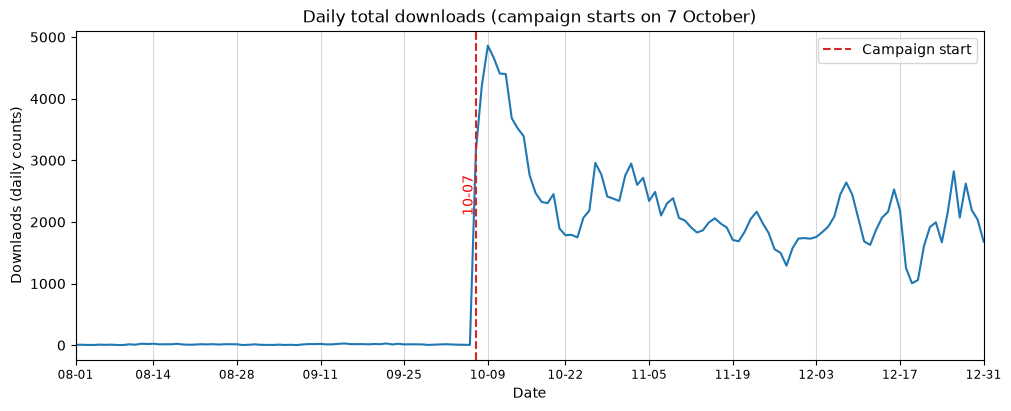

In [14]:
# [Presentation] Daily total downloads comparison before and after promotional campaign
fig, ax = plt.subplots(figsize=(10,4), layout="constrained")

# Daily total downloads
ax.plot(download_df.index, download_df.total_downloads)
ax.set(xlabel="Date", ylabel="Downlaods (daily counts)", title="Daily total downloads (campaign starts on 7 October)")

# Marking campaign start date on the graph
campaign_start = pd.Timestamp("2025-10-07")
ymin, ymax = ax.get_ylim()
ymid = (ymin + ymax) / 2
ax.axvline(campaign_start, linestyle="--", color="tab:red", label="Campaign start")
ax.text(campaign_start, ymid, campaign_start.strftime("%m-%d"), color="red", rotation=90, va="center", ha="right")

format_date_axis(ax, download_df.index, n_ticks=12)
ax.grid(alpha=0.5, axis="x")

plt.legend()
plt.show()

In [15]:
# [Presentation] Calculate daily downloads by monthly averages

totalDownload_monthly = download_df.resample("MS").sum()
totalDownload_monthly["avgDaily_totalDownloads"] = download_df.resample("MS").mean()

# Note: since promo_df only concerns the campaign duration, all data starts on 7 October (instead of 1 October)
paidDownload_monthly = promo_df.resample("MS")[["paid_downloads", "total_downloads"]].sum()
paidDownload_monthly["avgDaily_paidDownloads"] = promo_df.resample("MS")[["paid_downloads"]].mean()
paidDownload_monthly["avgDaily_totalDownloads"] = promo_df.resample("MS")[["total_downloads"]].mean()
nonpaidDownload_monthly = promo_df[["nonpaid_downloads"]].resample("MS").sum()
nonpaidDownload_monthly["avgDaily_nonpaidDownloads"] = promo_df.nonpaid_downloads.resample("MS").mean()

download_monthly = pd.merge(totalDownload_monthly, paidDownload_monthly, left_index=True, right_index=True, how="outer", suffixes=("", "_Oct7"))
download_monthly = pd.merge(download_monthly, nonpaidDownload_monthly, left_index=True, right_index=True, how="outer")
delta = download_df.loc["2025-10-01":"2025-10-06", "total_downloads"].sum()

# To compare between pre- and post-campaign download levels, I used September and October data (while excluding 1-6 October)
sep = download_monthly.loc["2025-09"].squeeze()
oct = download_monthly.loc["2025-10"].squeeze()
print(f"Between September and October (the campaign start), the number of total downloads increased by {100 * (oct["total_downloads"] - sep["total_downloads"]) / sep["total_downloads"]:.2f}%.")
print(f"Average daily total downloads went from {sep["avgDaily_totalDownloads"]:.2f} in September to {oct["avgDaily_totalDownloads_Oct7"]:.2f} in October, increasing by {(oct["avgDaily_totalDownloads_Oct7"] - sep["avgDaily_totalDownloads"]) / sep["avgDaily_totalDownloads"]:.2f} folds, excluding the 1-6 October non-campaign period.")
print(f"In October, {100* oct["paid_downloads"] / oct["total_downloads"]:.2f}% was paid downloads, and {100* oct["nonpaid_downloads"] / oct["total_downloads"]:.2f}% was organic downloads.")
print(f"Since the campaign started, daily organic traffic increased by {(oct["avgDaily_nonpaidDownloads"] - sep["avgDaily_totalDownloads"]) / sep["avgDaily_totalDownloads"]:.2f} folds in the first month, excluding the 1-6 October non-campaign period.")
download_monthly

Between September and October (the campaign start), the number of total downloads increased by 17362.20%.
Average daily total downloads went from 13.93 in September to 2917.24 in October, increasing by 208.37 folds, excluding the 1-6 October non-campaign period.
In October, 64.71% was paid downloads, and 35.20% was organic downloads.
Since the campaign started, daily organic traffic increased by 72.77 folds in the first month, excluding the 1-6 October non-campaign period.


,total_downloads,avgDaily_totalDownloads,paid_downloads,total_downloads_Oct7,avgDaily_paidDownloads,avgDaily_totalDownloads_Oct7,nonpaid_downloads,avgDaily_nonpaidDownloads
date,,,,,,,,
2025-08-01,367,11.838710,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-01,418,13.933333,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-01,72992,2354.580645,47236.0,72931.0,1889.440000,2917.240000,25695.0,1027.800000
2025-11-01,61170,2039.000000,41204.0,61170.0,1373.466667,2039.000000,19966.0,665.533333
2025-12-01,60905,1964.677419,33025.0,60905.0,1065.322581,1964.677419,27880.0,899.354839


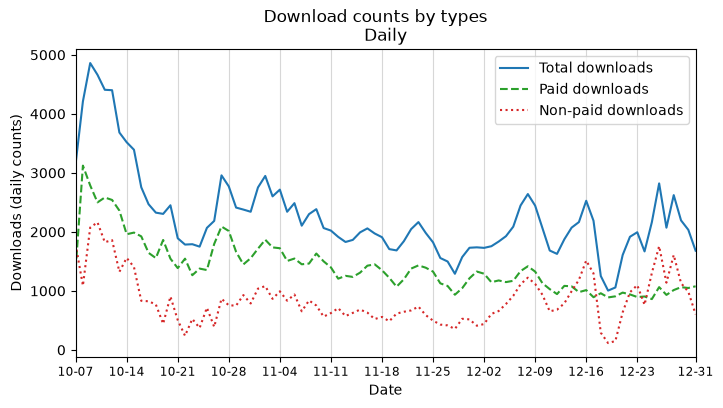

In [16]:
# [Presentation] Splitting total downloads by type
windows = [7, 30]

paidInst_df = sma_rolling_mean(promo_df[["paid_downloads"]], windows=windows, numerator="paid_downloads")
totalInst_df = sma_rolling_mean(promo_df[["total_downloads"]], windows=windows, numerator="total_downloads")
nonpaidInst_df = sma_rolling_mean(promo_df[["nonpaid_downloads"]], windows=windows, numerator="nonpaid_downloads")

fig, ax = plt.subplots(figsize=(8,4))

# ax[0,0] daily
ax.plot(promo_df.index, totalInst_df.total_downloads, label="Total downloads", color="tab:blue")
ax.plot(promo_df.index, paidInst_df.paid_downloads, label="Paid downloads", color="tab:green", linestyle="--")
ax.plot(promo_df.index, nonpaidInst_df.nonpaid_downloads, label="Non-paid downloads", color="tab:red", linestyle=":")
ax.set(xlabel="Date", ylabel="Downloads (daily counts)", title="Daily")

format_date_axis(ax, promo_df.index, n_ticks=13)
ax.legend()
ax.grid(alpha=0.5, axis="x")

plt.suptitle("Download counts by types")
plt.show()

### 1b. Campaign profitability: Cost, revenue, and profit

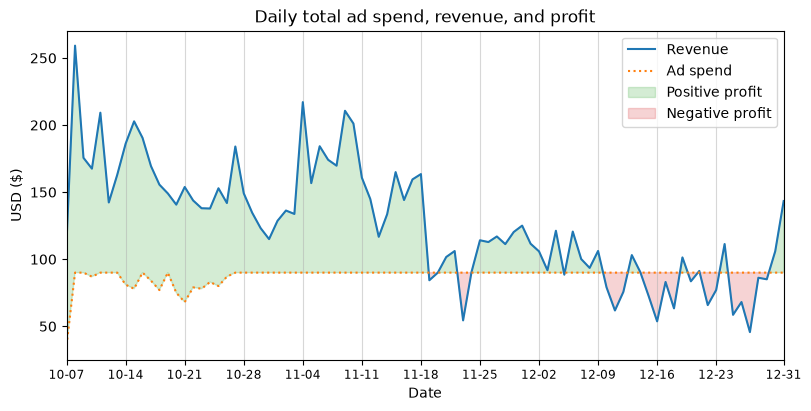

In [17]:
# [Presentation] Daily cost, revenue, and profit as absolutes
fig, ax = plt.subplots(figsize=(8,4), layout="constrained")
fill_condition = promo_df.trpd - promo_df.ad_spend

# ax[0] Absolutes
ax.plot(promo_df.index, promo_df.trpd, label="Revenue", color="tab:blue")
ax.plot(promo_df.index, promo_df.ad_spend, label="Ad spend", linestyle=":", color="tab:orange")
ax.fill_between(promo_df.index, promo_df.trpd, promo_df.ad_spend, label="Positive profit", where=(fill_condition >= 0), interpolate=True, color="tab:green", alpha=0.2)
ax.fill_between(promo_df.index, promo_df.trpd, promo_df.ad_spend, label="Negative profit", where=(fill_condition <= 0), interpolate=True, color="tab:red", alpha=0.2)
ax.set(xlabel="Date", ylabel="USD ($)", title="Daily total ad spend, revenue, and profit")

format_date_axis(ax, promo_df.index, n_ticks=13)
ax.grid(alpha=0.5, axis="x")

plt.legend()
plt.show()

In [18]:
# [Presentation] Monthly profits
profitability_monthly = promo_df.resample("MS")[["ad_spend", "trpd", "tppd"]].sum()
diff = profitability_monthly.diff()
pct_change = profitability_monthly.pct_change()
profitability_monthly = pd.merge(profitability_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
profitability_monthly = pd.merge(profitability_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pctChange"))

print(f"Total revenue during campaign: {profitability_monthly.trpd.sum()}")
print(f"Total cost during campaign: {profitability_monthly.ad_spend.sum()}")
print(f"Total profit during campaign: {profitability_monthly.tppd.sum()}")

profitability_monthly

Total revenue during campaign: 10872.438999999998
Total cost during campaign: 7563
Total profit during campaign: 3309.9139999999998


,ad_spend,trpd,tppd,ad_spend_diff,trpd_diff,tppd_diff,ad_spend_pctChange,trpd_pctChange,tppd_pctChange
date,,,,,,,,,
2025-10-01,2073,3999.515,1929.858,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,2700,4127.767,1426.667,627.0,128.252,-503.191,0.302460,0.032067,-0.260740
2025-12-01,2790,2745.157,-46.611,90.0,-1382.610,-1473.278,0.033333,-0.334953,-1.032671


Over the entire campaign period (7 Oct to 31 Dec), the campaign performance is as follows:
Revenue: 10872.439
Cost: 7563
Net profit: 3309.914
Return on Ad Spend (ROAS = Revenue ÷ Ad Spend): 143.76%


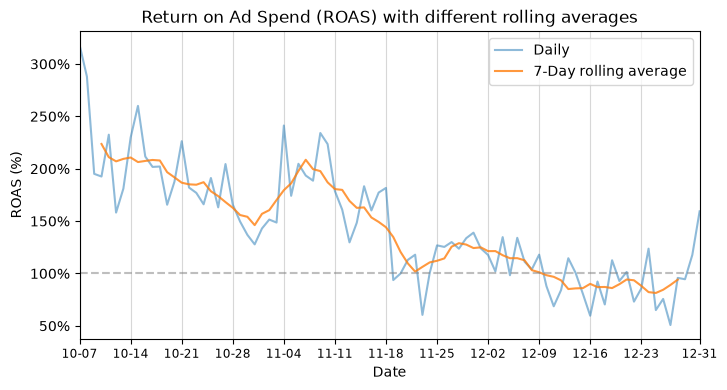

In [19]:
# [Presentation] Calculate and visualize ROAS
overall_roas = promo_df.trpd.sum() / promo_df.ad_spend.sum()

print(f"Over the entire campaign period (7 Oct to 31 Dec), the campaign performance is as follows:")
print(f"Revenue: {promo_df.trpd.sum()}")
print(f"Cost: {promo_df.ad_spend.sum()}")
print(f"Net profit: {promo_df.tppd.sum()}")
print(f"Return on Ad Spend (ROAS = Revenue ÷ Ad Spend): {overall_roas*100:.2f}%")

# Using moving averages to smooth out daily fluctuations but still highlight relevant trends. 
windows = [7]
roas_df = promo_df[["ad_spend", "trpd", "roas"]].copy()
numerators = list(roas_df.columns)
for a in numerators:
  roas_df = sma_rolling_mean(roas_df, windows=windows, numerator=a)

# Plot it
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(roas_df.index, roas_df.roas, label="Daily", alpha=0.5)
ax.plot(roas_df.index, roas_df.roas_sma_7d, label="7-Day rolling average", alpha=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(y=1, color="tab:gray", linestyle="--", alpha=0.5)
ax.set(xlabel="Date", ylabel="ROAS (%)", title="Return on Ad Spend (ROAS) with different rolling averages")

format_date_axis(ax, roas_df.index, n_ticks=13)
ax.legend()
ax.grid(alpha=0.5, axis="x")

plt.show()

## 2. Problem: Declining revenue
In this section, I explored two leading hypotheses for declining revenue (which was the reason for declining campaign profitability, shown in 3b).

Daily total revenue = ARPD $\times$ daily ad spend.

Given the above equation, I explored two hypotheses:
* Paid download users were spending less: if this is true, we should see a declining ARPD over time
* There were less paid downloads: if this is true, then we should see declining paid downloads, with other user engagement metrics (impressions, clicks, etc.) also decreasing over time

### 2a. Hypothesis 1: *"Paid download users were spending less"*

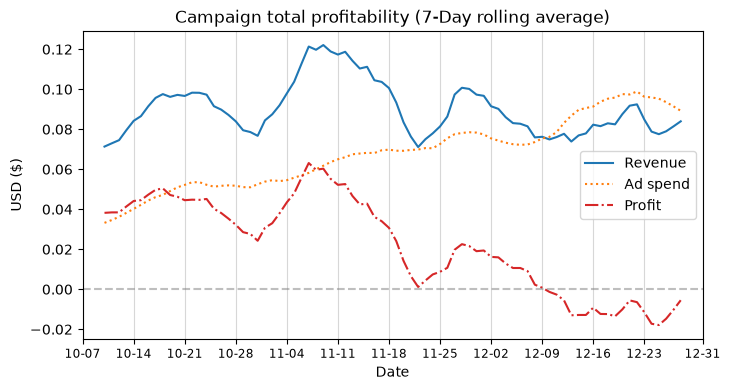

In [20]:
# [Presentation] Use rolling averages to smooth out daily fluctuations but retain key information
windows=[7]
profit_cols = ["ad_spend", "trpd", "tppd", "cpi", "arpd", "appd", "paid_downloads"]
profit_df = promo_df[profit_cols].copy()

for a in profit_cols:
  if a == "cpi":
    profit_df = sma_rolling_mean(profit_df, windows=windows, numerator="ad_spend", rate_mean=True, denominator="paid_downloads", name="cpi")
  elif a == "arpd":
    profit_df = sma_rolling_mean(profit_df, windows=windows, numerator="trpd", rate_mean=True, denominator="paid_downloads", name="arpd")
  elif a == "appd":
    profit_df = sma_rolling_mean(profit_df, windows=windows, numerator="tppd", rate_mean=True, denominator="paid_downloads", name="appd")
  else:
    pass

def campaign_profit_plots(a, df, rolling_avg, revenue, cost, profit):
  a.plot(df.index, df[revenue], label="Revenue", color="tab:blue")
  a.plot(df.index, df[cost], label="Ad spend", linestyle=":", color="tab:orange")
  a.plot(df.index, df[profit], label="Profit", linestyle="-.", color="tab:red")
  a.axhline(y=0, color="tab:gray", linestyle="--", alpha=0.5)
  a.set(xlabel="Date", ylabel="USD ($)")
  if rolling_avg == "Daily":
    a.set(title=f"Campaign total profitability (daily)")
  else:
    a.set(title=f"Campaign total profitability ({rolling_avg} rolling average)")

rolling_avg = "7-Day"

# Plot it
fig, ax = plt.subplots(figsize=(8,4))

revenue, cost, profit = "arpd_sma_7d", "cpi_sma_7d", "appd_sma_7d"

campaign_profit_plots(a=ax, df=profit_df, rolling_avg=rolling_avg, revenue=revenue, cost=cost, profit=profit)
format_date_axis(ax, profit_df.index, n_ticks=13)
ax.legend()
ax.grid(alpha=0.5, axis="x")

plt.show()

In [21]:
# [Presentation] Average profit per paid download by month
paidDownloads_monthly = promo_df.resample("MS")[["paid_downloads"]].sum()
profitability_monthly = promo_df.resample("MS")[["ad_spend", "trpd", "tppd"]].sum()

avgProfitability_monthly = pd.DataFrame()
avgProfitability_monthly["cpi"] = profitability_monthly["ad_spend"] / paidDownloads_monthly["paid_downloads"]
avgProfitability_monthly["arpd"] = profitability_monthly["trpd"] / paidDownloads_monthly["paid_downloads"]
avgProfitability_monthly["appd"] = profitability_monthly["tppd"] / paidDownloads_monthly["paid_downloads"]

diff = avgProfitability_monthly.diff()
pct_change = avgProfitability_monthly.pct_change()

avgProfitability_monthly = pd.merge(avgProfitability_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
avgProfitability_monthly = pd.merge(avgProfitability_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pctChange"))

print("Between October and December,")
print(f"ARPD total change {avgProfitability_monthly.arpd_diff.sum()}, total percentage change {100 * avgProfitability_monthly.arpd_diff.sum()/avgProfitability_monthly.loc["2025-10-01", "arpd"]:.2f}%.")
print(f"CPI total change {avgProfitability_monthly.cpi_diff.sum()}, total percentage change {100 * avgProfitability_monthly.cpi_diff.sum()/avgProfitability_monthly.loc["2025-10-01", "cpi"]:.2f}%.")

avgProfitability_monthly

Between October and December,
ARPD total change -0.001547304451390022, total percentage change -1.83%.
CPI total change 0.040595434306414706, total percentage change 92.50%.


,cpi,arpd,appd,cpi_diff,arpd_diff,appd_diff,cpi_pctChange,arpd_pctChange,appd_pctChange
date,,,,,,,,,
2025-10-01,0.043886,0.084671,0.040856,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,0.065528,0.100179,0.034624,0.021642,0.015508,-0.006231,0.493132,0.183155,-0.152517
2025-12-01,0.084481,0.083124,-0.001411,0.018954,-0.017055,-0.036036,0.289250,-0.170248,-1.040763


### 2b. Hypothesis 2: *“There were less paid downloads”*

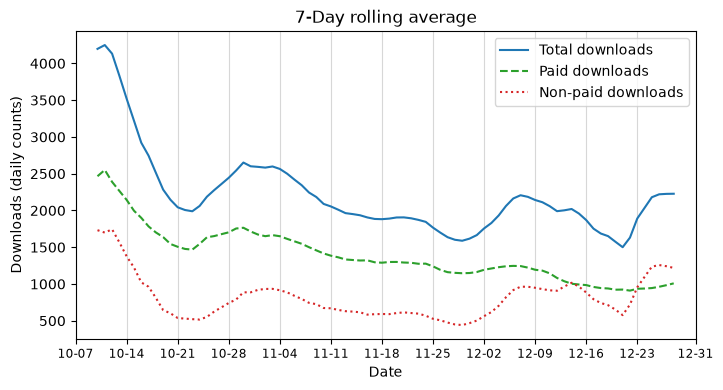

In [22]:
# [Presentation] To show the trends more clearly, I use simple moving averages (SMA) to smooth out daily fluctuations yet retain important trends.
windows = [7]

paidInst_df = sma_rolling_mean(promo_df[["paid_downloads"]], windows=windows, numerator="paid_downloads")
totalInst_df = sma_rolling_mean(promo_df[["total_downloads"]], windows=windows, numerator="total_downloads")
nonpaidInst_df = sma_rolling_mean(promo_df[["nonpaid_downloads"]], windows=windows, numerator="nonpaid_downloads")

# Plot it
fig, ax = plt.subplots(figsize=(8,4))

# ax[0] 7-day rolling avg
ax.plot(promo_df.index, totalInst_df.total_downloads_sma_7d, label="Total downloads", color="tab:blue")
ax.plot(promo_df.index, paidInst_df.paid_downloads_sma_7d, label="Paid downloads", color="tab:green", linestyle="--")
ax.plot(promo_df.index, nonpaidInst_df.nonpaid_downloads_sma_7d, label="Non-paid downloads", color="tab:red", linestyle=":")
ax.set(xlabel="Date", ylabel="Downloads (daily counts)", title="7-Day rolling average")

format_date_axis(ax, promo_df.index, n_ticks=13)
ax.legend()
ax.grid(alpha=0.5, axis="x")

plt.show()

In [23]:
# [Presentation] Daily paid download changes through months
paidDownload_monthly = download_monthly.loc["2025-10":"2025-12", ["paid_downloads", "avgDaily_paidDownloads"]].copy()
diff = paidDownload_monthly.diff()
pct_change = paidDownload_monthly.pct_change()

paidDownload_monthly = pd.merge(paidDownload_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
paidDownload_monthly = pd.merge(paidDownload_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pct_change"))

print(f"Monthly paid downloads changed by {100 * paidDownload_monthly.paid_downloads_diff.sum() / paidDownload_monthly.loc["2025-10-01", "paid_downloads"]:.2f}%.")
print(f"Monthly average Daily paid downloads changed by {100 * paidDownload_monthly.avgDaily_paidDownloads_diff.sum() / paidDownload_monthly.loc["2025-10-01", "avgDaily_paidDownloads"]:.2f}%.")
paidDownload_monthly

Monthly paid downloads changed by -30.09%.
Monthly average Daily paid downloads changed by -43.62%.


,paid_downloads,avgDaily_paidDownloads,paid_downloads_diff,avgDaily_paidDownloads_diff,paid_downloads_pct_change,avgDaily_paidDownloads_pct_change
date,,,,,,
2025-10-01,47236.0,1889.440000,NaN,NaN,NaN,NaN
2025-11-01,41204.0,1373.466667,-6032.0,-515.973333,-0.127699,-0.273083
2025-12-01,33025.0,1065.322581,-8179.0,-308.144086,-0.198500,-0.224355


#### Dissecting the ad funnel

In this following section, I further looked into what metrics tracking the ad funnel might explain the declining paid downloads.

The full ad funnel should be the following:

Ad spend --CPM--> Impression --CTR--> Clicks --CIR--> Paid Downloads

##### Top of the funnel (TOFU): Ad spend --CPM--> Impression
The very top part of the funnel is when money spent on ads successfully increased the number of impressions, or the number of times Facebook users have seen the ad. 

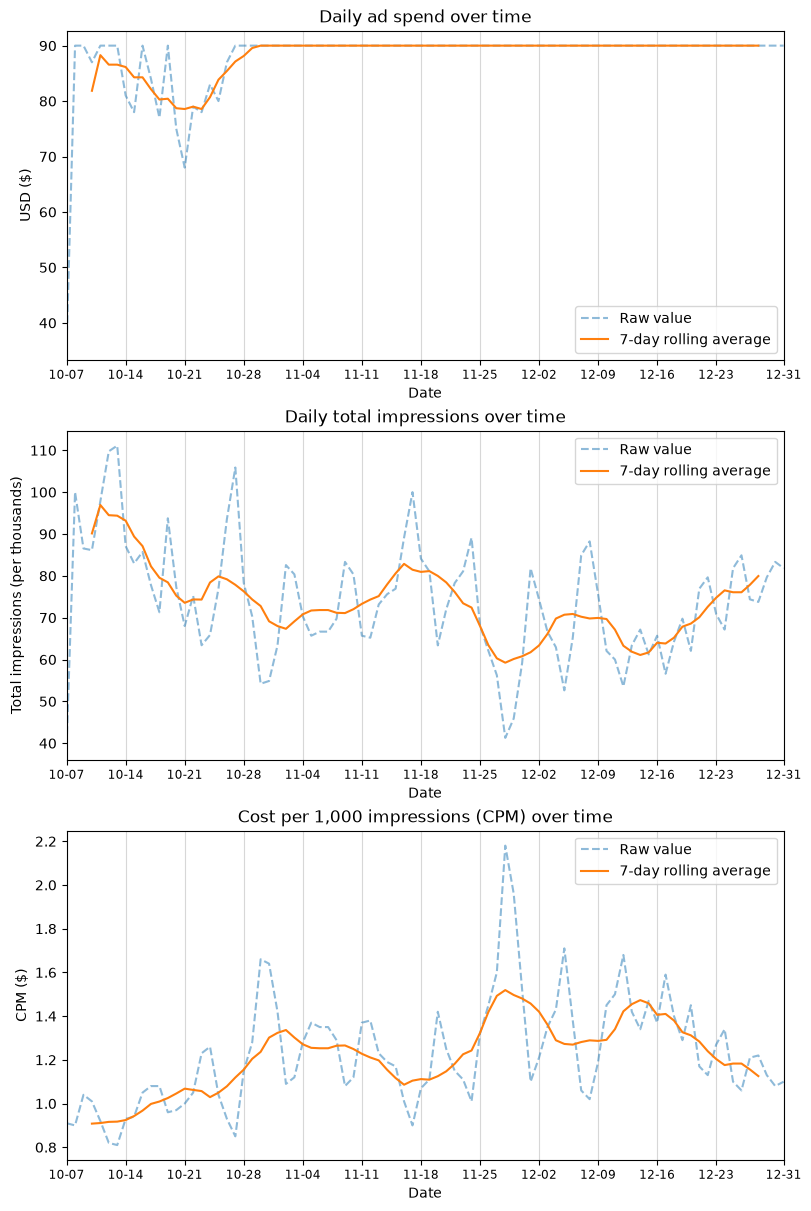

In [24]:
# [Presentation] Trend analysis
topFunnel_df = promo_df[["ad_spend", "total_impressions", "cpm"]].copy()
for col in topFunnel_df.columns:
  if col == "cpm":
    topFunnel_df = sma_rolling_mean(topFunnel_df, windows=[7], numerator="ad_spend", rate_mean=True, denominator="total_impressions", name=col)
  else:
    topFunnel_df = sma_rolling_mean(topFunnel_df, windows=[7], numerator=col)

fig, ax = plt.subplots(3,1, figsize=(8,12), layout="constrained")

ax[0].plot(topFunnel_df.index, topFunnel_df.ad_spend, label="Raw value", linestyle="--", alpha=0.5)
ax[0].plot(topFunnel_df.index, topFunnel_df.ad_spend_sma_7d, label="7-day rolling average")
ax[0].set(xlabel="Date", ylabel="USD ($)", title="Daily ad spend over time")
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.5, axis="x")

ax[1].plot(topFunnel_df.index, topFunnel_df.total_impressions / 1000, label="Raw value", linestyle="--", alpha=0.5)
ax[1].plot(topFunnel_df.index, topFunnel_df.total_impressions_sma_7d / 1000, label="7-day rolling average")
ax[1].set(xlabel="Date", ylabel="Total impressions (per thousands)", title="Daily total impressions over time")
ax[1].legend()
ax[1].grid(alpha=0.5, axis="x")

ax[2].plot(topFunnel_df.index, topFunnel_df.cpm, label="Raw value", linestyle="--", alpha=0.5)
ax[2].plot(topFunnel_df.index, topFunnel_df.cpm_sma_7d * 1000, label="7-day rolling average")
ax[2].set(xlabel="Date", ylabel="CPM ($)", title="Cost per 1,000 impressions (CPM) over time")
ax[2].legend()
ax[2].grid(alpha=0.5, axis="x")

for a in ax.flat:
  format_date_axis(a, topFunnel_df.index, n_ticks=13)

plt.show()

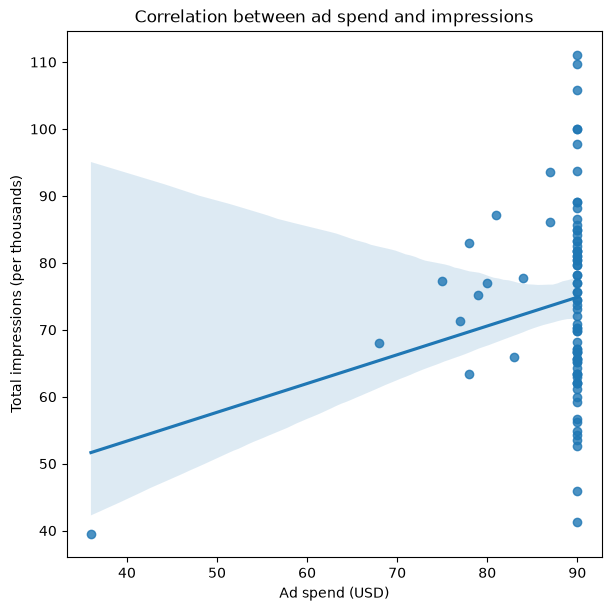

In [25]:
# [Presentation] Correlation analysis
fig, ax = plt.subplots(figsize=(6,6), layout="constrained")

sns.regplot(x=topFunnel_df.ad_spend, y=topFunnel_df.total_impressions / 1000)
ax.set(xlabel="Ad spend (USD)", ylabel="Total impressions (per thousands)", title="Correlation between ad spend and impressions")

plt.show()

In [26]:
# [Presentation] Correlation analysis
results = []
pairs = [["ad_spend", "total_impressions"], ["ad_spend_sma_7d", "total_impressions_sma_7d"]]

for pair in pairs:
  f1 = pair[0]
  f2 = pair[1]
  r, p = stats.pearsonr(topFunnel_df[f1].dropna(), topFunnel_df[f2].dropna())
  results.append({"Feature 1": f1, "Feature 2": f2, "Correlation": r, "p-value": p})

topFunnel_corr_df = pd.DataFrame(results)

topFunnel_corr_df

,Feature 1,Feature 2,Correlation,p-value
0,ad_spend,total_impressions,0.214026,0.047844
1,ad_spend_sma_7d,total_impressions_sma_7d,-0.405773,0.000188


##### Middle of the funnel (MOFU): Impressions --CTR--> Clicks
The middle layer concerns the first meaningful conversion: from impressions to clicking on the ad, which presumably leads the user to a landing page where they can download the app.

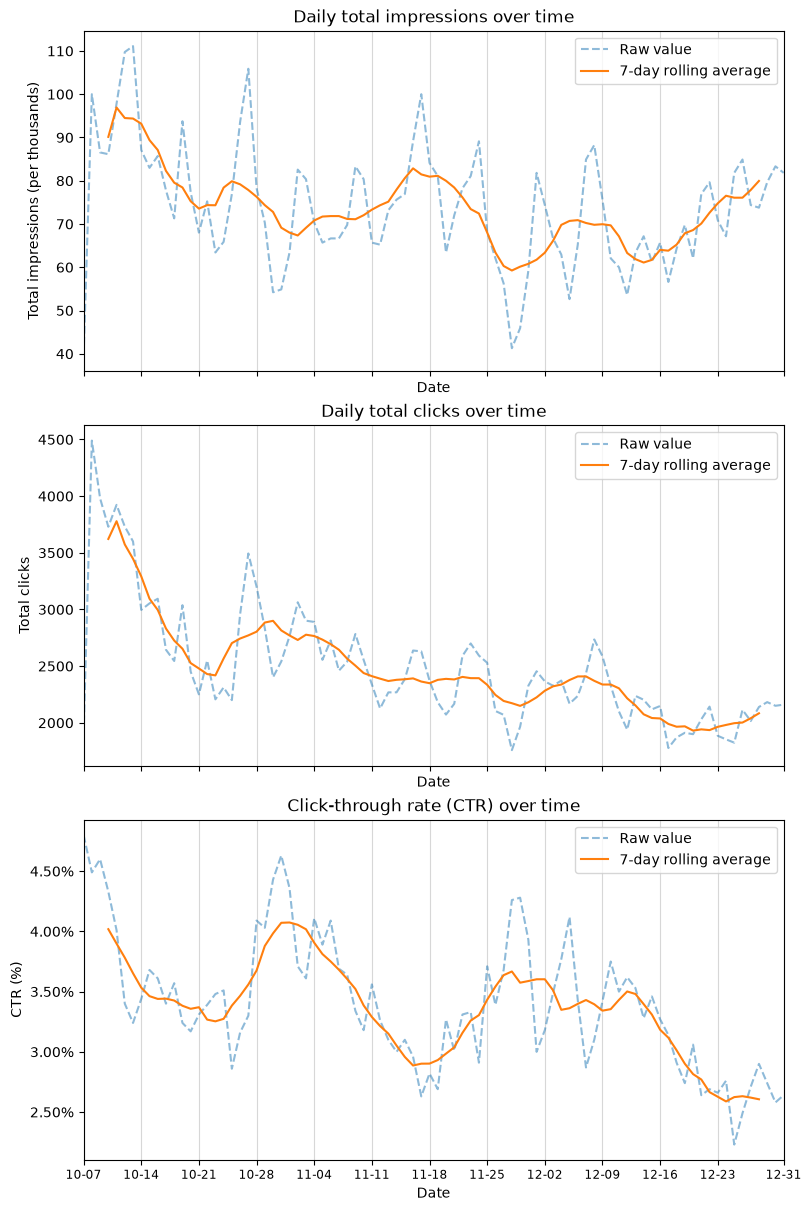

In [27]:
# [Presentation] Trend analysis
midFunnel_df = promo_df[["total_impressions", "total_clicks", "ctr"]].copy()
for col in midFunnel_df.columns:
  if col == "ctr":
    midFunnel_df = sma_rolling_mean(midFunnel_df, windows=[7], numerator="total_clicks", rate_mean=True, denominator="total_impressions", name=col)
  else:
    midFunnel_df = sma_rolling_mean(midFunnel_df, windows=[7], numerator=col)

fig, ax = plt.subplots(3,1, figsize=(8,12), sharex=True, layout="constrained")

ax[0].plot(midFunnel_df.index, midFunnel_df.total_impressions / 1000, label="Raw value", linestyle="--", alpha=0.5)
ax[0].plot(midFunnel_df.index, midFunnel_df.total_impressions_sma_7d / 1000, label="7-day rolling average")
ax[0].set(xlabel="Date", ylabel="Total impressions (per thousands)", title="Daily total impressions over time")
ax[0].legend()
ax[0].grid(alpha=0.5, axis="x")

ax[1].plot(midFunnel_df.index, midFunnel_df.total_clicks, label="Raw value", linestyle="--", alpha=0.5)
ax[1].plot(midFunnel_df.index, midFunnel_df.total_clicks_sma_7d, label="7-day rolling average")
ax[1].set(xlabel="Date", ylabel="Total clicks", title="Daily total clicks over time")
ax[1].legend()
ax[1].grid(alpha=0.5, axis="x")

ax[2].plot(midFunnel_df.index, midFunnel_df.ctr, label="Raw value", linestyle="--", alpha=0.5)
ax[2].plot(midFunnel_df.index, midFunnel_df.ctr_sma_7d, label="7-day rolling average")
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[2].set(xlabel="Date", ylabel="CTR (%)", title="Click-through rate (CTR) over time")
ax[2].legend()
ax[2].grid(alpha=0.5, axis="x")

format_date_axis(ax[1], midFunnel_df.index, n_ticks=13)
format_date_axis(ax[2], midFunnel_df.index, n_ticks=13)
plt.show()

In [28]:
# [Presentation] Month-on-month CTR change
midFunnel_monthly = midFunnel_df[["total_impressions", "total_clicks"]].resample('MS').sum()
midFunnel_monthly["ctr"] = midFunnel_monthly["total_clicks"] / midFunnel_monthly["total_impressions"]

diff = midFunnel_monthly.diff()
pct_change = midFunnel_monthly.pct_change()

midFunnel_monthly = pd.merge(midFunnel_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
midFunnel_monthly = pd.merge(midFunnel_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pct_change"))

print(f"Average click-through rate by month changed by {100 * midFunnel_monthly.ctr_diff.sum() / midFunnel_monthly.loc["2025-10-01", "ctr"]:.2f}%.")
midFunnel_monthly

Average click-through rate by month changed by -17.35%.


,total_impressions,total_clicks,ctr,total_impressions_diff,total_clicks_diff,ctr_diff,total_impressions_pct_change,total_clicks_pct_change,ctr_pct_change
date,,,,,,,,,
2025-10-01,2.013412e+06,74124.005068,0.036815,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,2.156786e+06,73322.960388,0.033996,143373.558746,-801.044679,-0.002819,0.071209,-0.010807,-0.076564
2025-12-01,2.192522e+06,66714.043759,0.030428,35736.709356,-6608.916630,-0.003568,0.016569,-0.090134,-0.104965


##### Bottom of the funnel (BOFU): Clicks --CIR--> Install
The bottom part of the ad funnel is another key conversion: from clicks to downloads, which is key to the ad campaign.

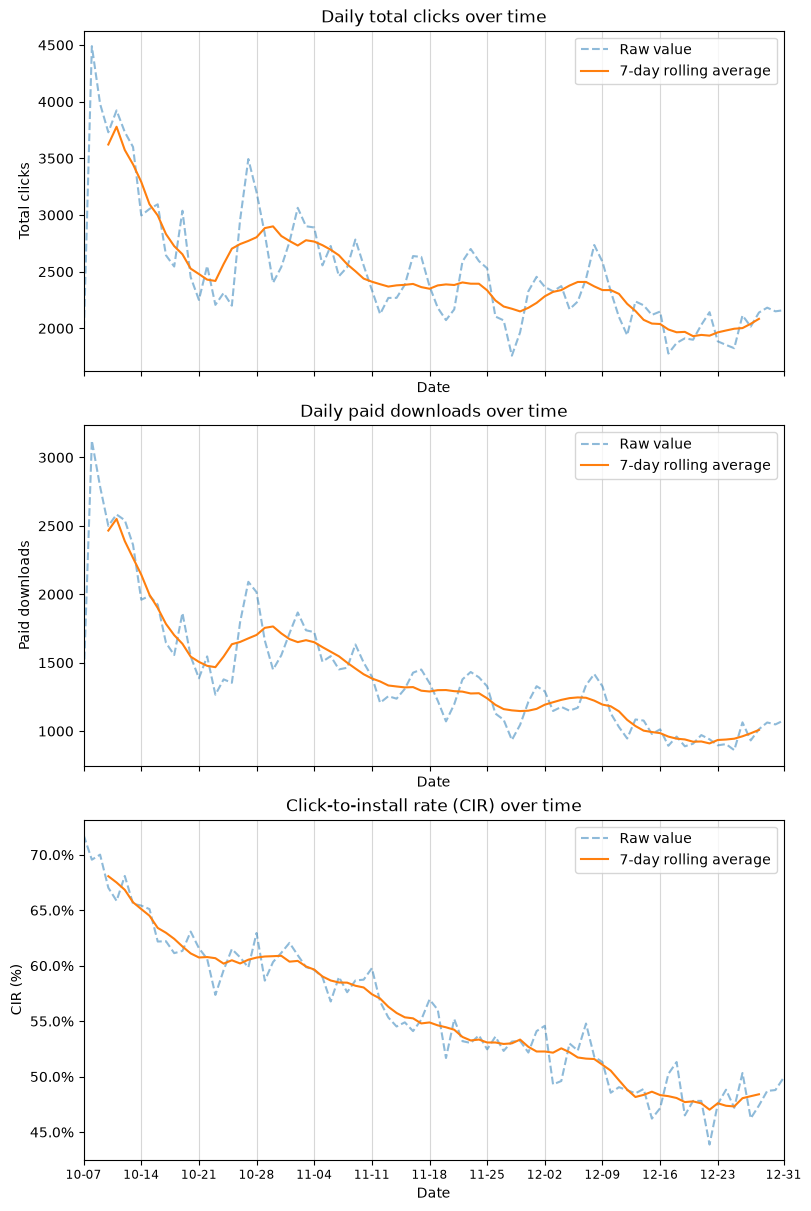

In [29]:
# Trend analysis
btmFunnel_df = promo_df[["total_clicks", "paid_downloads", "cir"]].copy()
for col in btmFunnel_df.columns:
  if col == "cir":
    btmFunnel_df = sma_rolling_mean(btmFunnel_df, windows=[7], numerator="paid_downloads", rate_mean=True, denominator="total_clicks", name=col)
  else:
    btmFunnel_df = sma_rolling_mean(btmFunnel_df, windows=[7], numerator=col)

fig, ax = plt.subplots(3,1, figsize=(8,12), sharex=True, layout="constrained")

ax[0].plot(btmFunnel_df.index, btmFunnel_df.total_clicks, label="Raw value", linestyle="--", alpha=0.5)
ax[0].plot(btmFunnel_df.index, btmFunnel_df.total_clicks_sma_7d, label="7-day rolling average")
ax[0].set(xlabel="Date", ylabel="Total clicks", title="Daily total clicks over time")
ax[0].legend()
ax[0].grid(alpha=0.5, axis="x")

ax[1].plot(btmFunnel_df.index, btmFunnel_df.paid_downloads, label="Raw value", linestyle="--", alpha=0.5)
ax[1].plot(btmFunnel_df.index, btmFunnel_df.paid_downloads_sma_7d, label="7-day rolling average")
ax[1].set(xlabel="Date", ylabel="Paid downloads", title="Daily paid downloads over time")
ax[1].legend()
ax[1].grid(alpha=0.5, axis="x")

ax[2].plot(btmFunnel_df.index, btmFunnel_df.cir, label="Raw value", linestyle="--", alpha=0.5)
ax[2].plot(btmFunnel_df.index, btmFunnel_df.cir_sma_7d, label="7-day rolling average")
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[2].set(xlabel="Date", ylabel="CIR (%)", title="Click-to-install rate (CIR) over time")
ax[2].legend()
ax[2].grid(alpha=0.5, axis="x")

format_date_axis(ax[1], btmFunnel_df.index, n_ticks=13)
format_date_axis(ax[2], midFunnel_df.index, n_ticks=13)
plt.show()

In [30]:
# [Presentation] Month-on-month CIR change
btmFunnel_monthly = btmFunnel_df[["total_clicks", "paid_downloads"]].resample('MS').sum()
btmFunnel_monthly["cir"] = btmFunnel_monthly["paid_downloads"] / btmFunnel_monthly["total_clicks"]

diff = btmFunnel_monthly.diff()
pct_change = btmFunnel_monthly.pct_change()

btmFunnel_monthly = pd.merge(btmFunnel_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
btmFunnel_monthly = pd.merge(btmFunnel_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pct_change"))

print(f"Average click-through rate by month changed by {100 * btmFunnel_monthly.cir_diff.sum() / btmFunnel_monthly.loc["2025-10-01", "cir"]:.2f}%.")
btmFunnel_monthly

Average click-through rate by month changed by -22.32%.


,total_clicks,paid_downloads,cir,total_clicks_diff,paid_downloads_diff,cir_diff,total_clicks_pct_change,paid_downloads_pct_change,cir_pct_change
date,,,,,,,,,
2025-10-01,74124.005068,47236,0.637256,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,73322.960388,41204,0.561952,-801.044679,-6032.0,-0.075304,-0.010807,-0.127699,-0.118169
2025-12-01,66714.043759,33025,0.495023,-6608.916630,-8179.0,-0.066929,-0.090134,-0.198500,-0.119101


## 3. Additional analysis
In this section, I set out to investigate further the weekly pattern with seen in user engagement metrics, especailly most pronounced in impressions.

In [31]:
# Creating full adFunnel_df for further analysis
adFunnel_df = pd.merge(topFunnel_df, btmFunnel_df, left_index=True, right_index=True)
adFunnel_df = pd.merge(adFunnel_df, midFunnel_df[["ctr", "ctr_sma_7d"]], left_index=True, right_index=True)
adFunnel_df = pd.merge(adFunnel_df, promo_df[["cpi"]], left_index=True, right_index=True)

reorder_list = ["ad_spend", "total_impressions", "total_clicks", "paid_downloads", "cpm", "ctr", "cir", "cpi",
"ad_spend_sma_7d", "total_impressions_sma_7d", "total_clicks_sma_7d", "paid_downloads_sma_7d", "cpm_sma_7d", "ctr_sma_7d", "cir_sma_7d"]

adFunnel_df = adFunnel_df[reorder_list]

adFunnel_df

,ad_spend,total_impressions,total_clicks,paid_downloads,cpm,ctr,cir,cpi,ad_spend_sma_7d,total_impressions_sma_7d,total_clicks_sma_7d,paid_downloads_sma_7d,cpm_sma_7d,ctr_sma_7d,cir_sma_7d
date,,,,,,,,,,,,,,,
2025-10-07,36,39560.439560,1898.901099,1363,0.91,0.0480,0.717784,0.026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-08,90,100000.000000,4490.000000,3123,0.90,0.0449,0.695546,0.029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-09,90,86538.461538,3980.769231,2787,1.04,0.0460,0.700116,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-10,87,86138.613861,3729.801980,2500,1.01,0.0433,0.670277,0.035,81.857143,90132.972941,3622.000816,2465.428571,0.000908,0.040185,0.680681
2025-10-11,90,97826.086957,3922.826087,2583,0.92,0.0401,0.658454,0.035,88.285714,96923.877889,3778.747664,2550.714286,0.000911,0.038987,0.675016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,90,74380.165289,2015.702479,932,1.21,0.0271,0.462370,0.097,90.000000,77859.718489,2039.967910,984.000000,0.001156,0.026201,0.482361
2025-12-28,90,73770.491803,2139.344262,1014,1.22,0.0290,0.473977,0.089,90.000000,79953.147448,2083.720575,1008.714286,0.001126,0.026062,0.484093
2025-12-29,90,79646.017699,2182.300885,1063,1.13,0.0274,0.487101,0.085,NaN,NaN,NaN,NaN,NaN,NaN,NaN


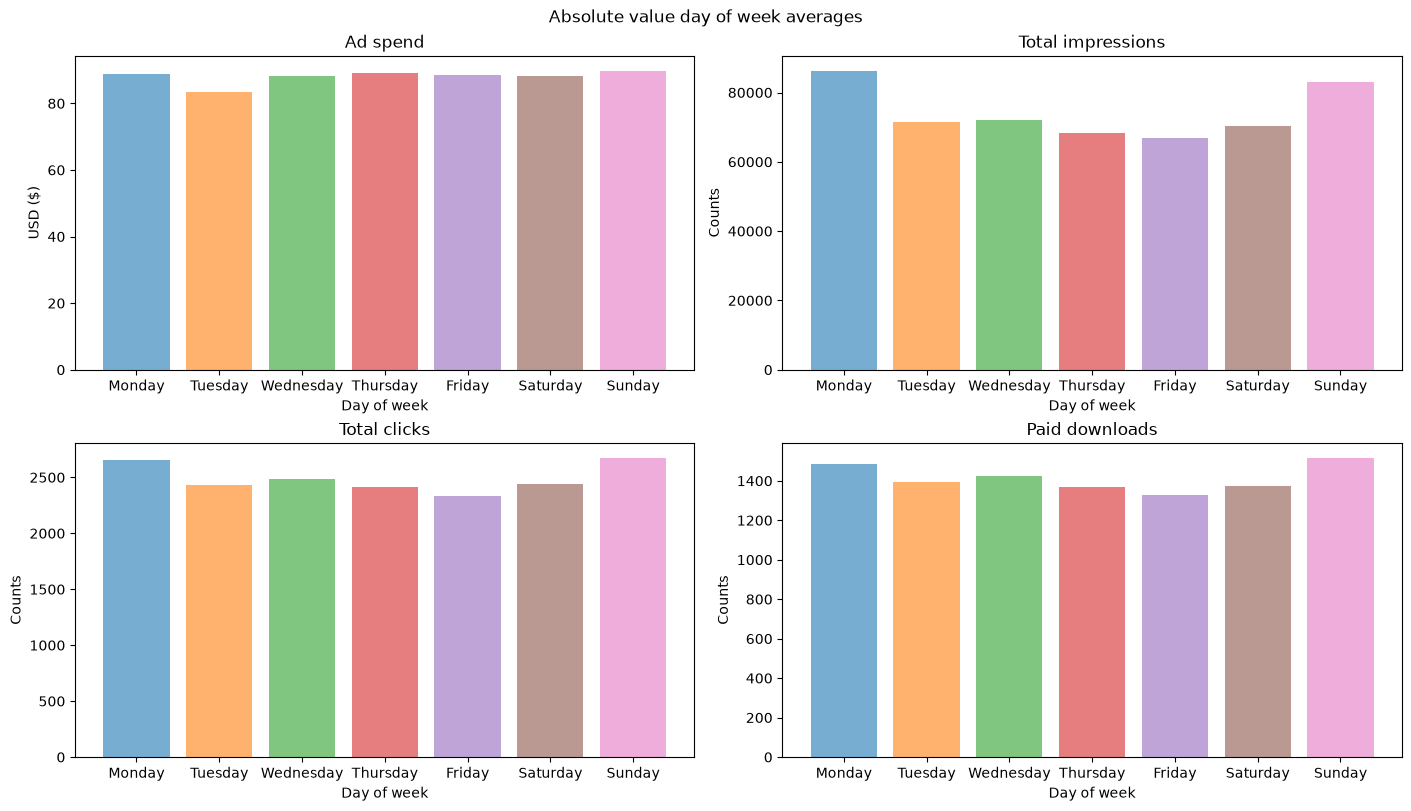

In [32]:
# [Presentation] Group by weekday: absolutes
df = adFunnel_df.copy()

absolute_cols = ["ad_spend", "total_impressions", "total_clicks", "paid_downloads"]
weekly_absolutes = df[absolute_cols].groupby(df.index.weekday).mean()
weekly_absolutes.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(2,2, figsize=(14,8), layout="constrained")

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

for i, a in enumerate(ax.flat):
  col = list(weekly_absolutes.columns)[i]
  col_label = col.replace("_", " ").capitalize()
  a.bar(x=weekly_absolutes.index, height=weekly_absolutes[col], color=colors, alpha=0.6)
  if col == "ad_spend":
    a.set_ylabel("USD ($)")
  else:
    a.set_ylabel("Counts")
  a.set(xlabel="Day of week", title=f"{col_label}")

plt.suptitle("Absolute value day of week averages")
plt.show()

In [33]:
# [Presentation] Let's verify if total impressions' weekday differences are statistically significant
df = adFunnel_df[["total_impressions"]].copy()

groups = [g.values for _, g in df["total_impressions"].groupby(df.index.weekday)]
results = stats.tukey_hsd(*groups)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pvals = pd.DataFrame(results.pvalue, index=days, columns=days)

pvals[pvals < 0.05]

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,NaN,NaN,NaN,0.013016,0.005419,0.045191,NaN
Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thu,0.013016,NaN,NaN,NaN,NaN,NaN,NaN
Fri,0.005419,NaN,NaN,NaN,NaN,NaN,0.036914
Sat,0.045191,NaN,NaN,NaN,NaN,NaN,NaN
Sun,NaN,NaN,NaN,NaN,0.036914,NaN,NaN


In [34]:
# Let's verify if total clicks' weekday differences are statistically significant
df = adFunnel_df[["total_clicks"]].copy()

groups = [g.values for _, g in df["total_clicks"].groupby(df.index.weekday)]
results = stats.tukey_hsd(*groups)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pvals = pd.DataFrame(results.pvalue, index=days, columns=days)

pvals[pvals < 0.05]

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fri,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Let's verify if paid downloads' weekday differences are statistically significant
df = adFunnel_df[["paid_downloads"]].copy()

groups = [g.values for _, g in df["paid_downloads"].groupby(df.index.weekday)]
results = stats.tukey_hsd(*groups)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pvals = pd.DataFrame(results.pvalue, index=days, columns=days)

pvals[pvals < 0.05]

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fri,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# End of analysis